<a href="https://colab.research.google.com/github/elangbijak4/multi-agent-AI/blob/main/Optimasi1_Model_pada_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 000 | Loss: 171.1271 | w=-0.660, b=-0.416
Epoch 020 | Loss: 3.3769 | w=2.939, b=-0.347
Epoch 040 | Loss: 3.2687 | w=3.025, b=-0.301
Epoch 060 | Loss: 3.2636 | w=3.028, b=-0.270
Epoch 080 | Loss: 3.2614 | w=3.028, b=-0.249
Epoch 100 | Loss: 3.2604 | w=3.028, b=-0.235
Epoch 120 | Loss: 3.2600 | w=3.028, b=-0.226
Epoch 140 | Loss: 3.2598 | w=3.028, b=-0.220
Epoch 160 | Loss: 3.2597 | w=3.028, b=-0.216
Epoch 180 | Loss: 3.2597 | w=3.028, b=-0.213


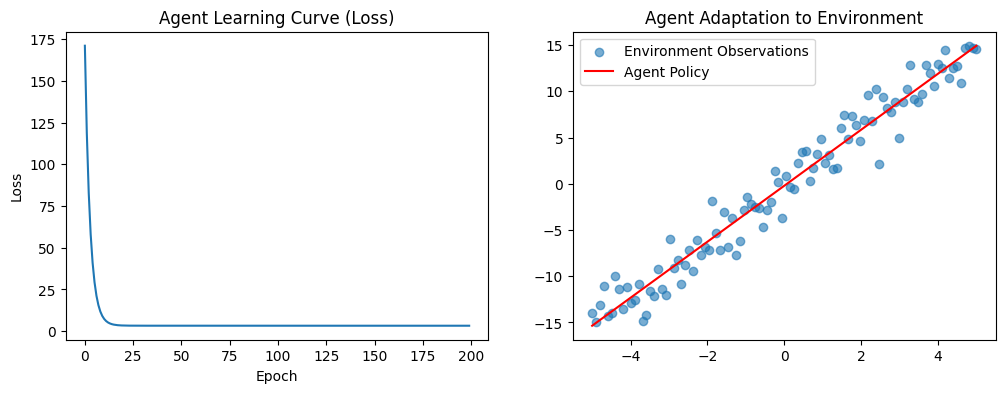

In [1]:
# ============================================================
# AGENT-BASED MODEL OPTIMIZATION DEMO
# Parameter Optimization as Rational Agent Behavior
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Environment (World)
# ----------------------------
# Simple regression world: y = 3x + noise
np.random.seed(42)
X = np.linspace(-5, 5, 100)
y_true = 3 * X
y = y_true + np.random.normal(0, 2, size=len(X))

# ----------------------------
# 2. Agent Definition
# ----------------------------
class LearningAgent:
    def __init__(self, lr=0.01):
        self.w = np.random.randn()   # parameter (belief)
        self.b = np.random.randn()
        self.lr = lr
        self.loss_history = []

    def predict(self, x):
        return self.w * x + self.b

    def loss(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)

    def perceive(self, X, y):
        y_pred = self.predict(X)
        return self.loss(y_pred, y)

    def act(self, X, y):
        # Gradient computation (agent local reasoning)
        y_pred = self.predict(X)
        dw = 2 * np.mean((y_pred - y) * X)
        db = 2 * np.mean(y_pred - y)

        # Parameter update (agent action)
        self.w -= self.lr * dw
        self.b -= self.lr * db

    def learn(self, X, y, epochs=100):
        for epoch in range(epochs):
            loss = self.perceive(X, y)
            self.loss_history.append(loss)
            self.act(X, y)

            if epoch % 20 == 0:
                print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | w={self.w:.3f}, b={self.b:.3f}")

# ----------------------------
# 3. Training the Agent
# ----------------------------
agent = LearningAgent(lr=0.01)
agent.learn(X, y, epochs=200)

# ----------------------------
# 4. Visualization
# ----------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(agent.loss_history)
plt.title("Agent Learning Curve (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.scatter(X, y, label="Environment Observations", alpha=0.6)
plt.plot(X, agent.predict(X), color='red', label="Agent Policy")
plt.legend()
plt.title("Agent Adaptation to Environment")

plt.show()